### QICK Standard ZCU111 Firmware + FFT/Spectrum Analysis

This firmware is a standard ZCU111 firmware (with less SGv6 though to make room for the FFT logic) 

There's an option to connect ADC_224_0 to a Readout path to capture data with the tProcessor.

See examples to extract data from the different points.

<!-- ![alt text](images/std_111_bread_small.png "Block Diagram") -->
<!-- ![alt text](images/qick_tprocv2_111_fft_spectrum_diagram.png "Block Diagram") -->
<img src="images/qick_diagrams-QICK_TPROCV2_111_FFT_SPECTRUM.drawio.png" alt="Placeholder" width="1200" height="1000">


In [1]:
import sys
import os

# Remote VSCode needs the current file path to be appended explicitly to find modules in files (os.getcwd() does not work)
# sys.path.append('/home/xilinx/jupyter_notebooks/qick-tools/qick_tprocv2_111_fft_spectrum/soft')
sys.path.append('../soft')

print(os.getcwd())

USE_LOCAL_QICK = True

QICK_WORKSPACE = "/home/dmartin2/qick_internal_b_51_fft"
# QICK_WORKSPACE = "/home/dmartin2/Projects/qick_internal_b_51_fft_readout"
QICK_TOOLS = QICK_WORKSPACE + "/qick-tools_b_6_fft"

if USE_LOCAL_QICK:
    import sys
    import os
    print(sys.path.insert(0,QICK_WORKSPACE + "/qick_lib"))
    print(sys.path.insert(0,QICK_TOOLS + "/qick_tprocv2_111_fft_spectrum/soft"))
    print(sys.path)

# jupyter setup boilerplate
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fftshift, fft

from qick import *
# the main program class
from qick.asm_v2 import AveragerProgramV2
# for defining sweeps
from qick.asm_v2 import QickSpan, QickSweep1D

print(qick.get_version())

# from qick.spectrum import SpectrumSoc, DualChain
# from qick.fft_helpers import *
from fft_helpers import *

import pynq
pynq.pl_server.global_state.clear_global_state()

/home/xilinx/jupyter_notebooks
None
None
['/home/dmartin2/qick_internal_b_51_fft/qick-tools_b_6_fft/qick_tprocv2_111_fft_spectrum/soft', '/home/dmartin2/qick_internal_b_51_fft/qick_lib', '/home/xilinx/jupyter_notebooks', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/usr/local/share/pynq-venv/lib/python3.10/site-packages', '/usr/local/lib/python3.10/dist-packages', '/usr/lib/python3/dist-packages', '/usr/lib/python3.10/dist-packages', '../soft']
0.2.375


In [2]:
USE_PYRO = False

if USE_PYRO:
    from qick.pyro import make_proxy
    # soc, soccfg = make_proxy(ns_host="pynq4x2.dhcp.fnal.gov", ns_port=8888, proxy_name="myqick")
    # soc, soccfg = make_proxy(ns_host="pynq216-6.dhcp.fnal.gov", ns_port=8888, proxy_name="myqick")
    soc, soccfg = make_proxy(ns_host="pynq111-4.dhcp.fnal.gov", ns_port=8888, proxy_name="myqick")
else:
    from spectrum import SpectrumSoc
    # soc = SpectrumSoc(bitfile='/home/dmartin2/fw/qick_tprocv2_111_fft_spectrum_260224_1/qick_111.bit')    # original project but reconstructed
    soc = SpectrumSoc(bitfile='/home/dmartin2/fw/qick_tprocv2_111_fft_spectrum_260302_1/qick_111.bit')    # added accumulator overflow check
    soccfg = soc

print(soccfg)


RFSoC PLLs are not locked, configuring reference clock chips (this is normal after power cycle)
LMK04208 clock reference = 122.880 MHz, LMX2594 clock synth = 204.800 MHz
QICK running on ZCU111, software version 0.2.375

Firmware configuration (built Mon Mar  2 18:01:16 2026):

	Global clocks (MHz): tProc dispatcher timing 384.000, RF reference 204.800
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 0, DAC tile 1], [ADC tile 0, ADC tile 1, ADC tile 2]

	4 signal generator channels:
	0:	axis_signal_gen_v6 - fs=6144.000 Msps, fabric=384.000 MHz
		envelope memory: 16384 complex samples (2.667 us)
		32-bit DDS, range=6144.000 MHz
		DAC tile 0, blk 0 is DAC228_T0_CH0, or RF board DAC port 0
	1:	axis_signal_gen_v6 - fs=6144.000 Msps, fabric=384.000 MHz
		envelope memory: 16384 complex samples (2.667 us)
		32-bit DDS, range=6144.000 MHz
		DAC tile 0, blk 1 is DAC228_T0_CH1, or RF board DAC port 1
	2:	axis_signal_gen_v6 - fs=6144.000 Msps, fabric=384.000 MHz
		envelop

In [3]:
#########################
### Define dual chain ###
#########################
# chain = DualChain(soc,soc['analysis'][0],soc['synthesis'][0])
# chain = DualChain(soc,soc['analysis'][0],soc['synthesis'][1])
chain = DualChain(soc,soccfg['analysis'][0],soccfg['synthesis'][2])


[ 1994.-1738.j -2598. -502.j  1154.+2391.j  1218.-2383.j -2622. +466.j]
pfb_channel: 10 / FC: 256
AbsPfbAnalysis: f = 300 MHz, fd = -724.0 MHz, k = 10
[ 248.-216.j  307.+117.j   41.+327.j -269.+190.j -295.-148.j]
AbsPfbAnalysis: f = 300 MHz, fd = -724.0 MHz, k = 10
[-373.+542.j -373.+541.j -373.+542.j -373.+542.j -373.+542.j]
[39087.  10676.7  2848.8  2401.6  2412.1]
Peek found at F1 = 256.000, Y1 = -42.012
FFT Resolution: 488.28125 Hz


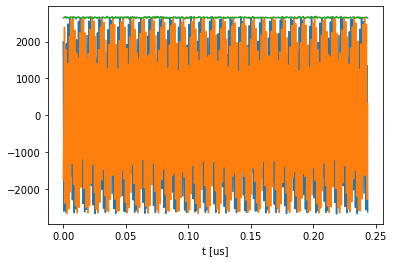

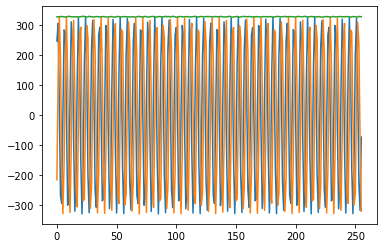

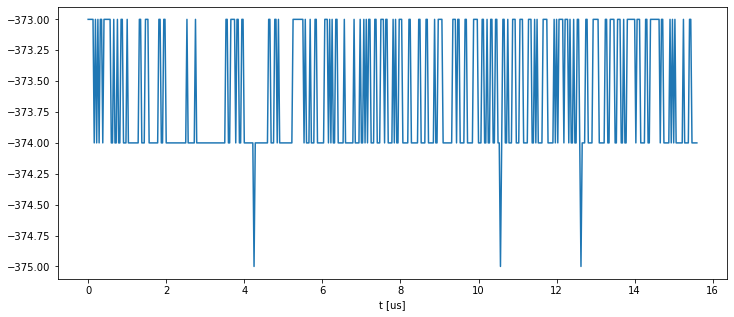

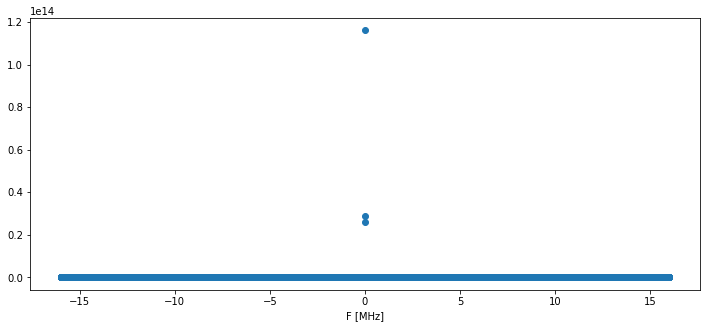

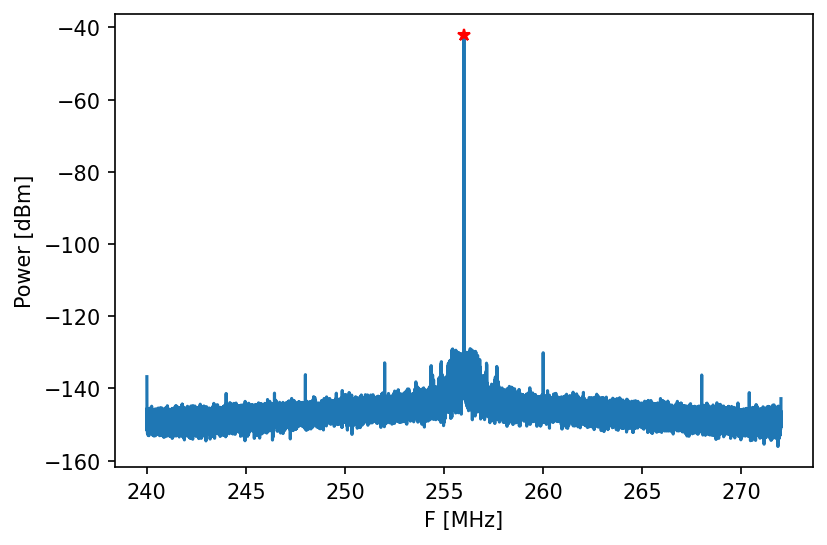

In [4]:
###############################
### Single Channel Zoom FFT ###
###############################
# Output frequency.
# fout = 14.5
fout = 300
chain.set_tone(f=fout, g=0.5)

# create directory if it doesnt exist
if not os.path.exists(QICK_TOOLS + "/qick_tprocv2_111_fft_spectrum/notebooks/data/f_"+str(fout)):
    os.makedirs(QICK_TOOLS + "/qick_tprocv2_111_fft_spectrum/notebooks/data/f_"+str(fout))

###############################
# Get ADC output data
[xi,xq] = chain.get_data_adc()
x_adc_t = xi + 1j*xq

# (for Debug)
plt.figure(0)
t = np.arange(len(x_adc_t))/chain.fs
plt.plot(t[:500],xi[:500])
plt.plot(t[:500],xq[:500])
plt.plot(t[:500],np.abs(x_adc_t[:500]))
plt.xlabel("t [us]")

print(x_adc_t[:5])
np.savetxt(QICK_TOOLS + "/qick_tprocv2_111_fft_spectrum/notebooks/data/f_"+str(fout)+"/x_adc_t_data.txt", x_adc_t)
###############################

# Configure PFB output scaling
chain.analysis.qout(6)

# Compute channel center frequency.
pfb_channel = chain.analysis.freq2ch(fout)
FC = chain.analysis.ch2freq(pfb_channel)
print("pfb_channel: %d / FC: %d"%(pfb_channel,FC))

# # DEBUG
# chain.analysis.set_ddscic_ddsfreq(f=10e6)
# chain.analysis.set_ddscic_outsel(data="dds", cic="no")
# [xi,xq] = chain.get_bin_pfb(fout, verbose=True)
# plt.figure()
# plt.plot(xi[:100])

###############################
# DEBUG
chain.analysis.set_ddscic_outsel(data="input", cic="no")
[xi,xq] = chain.get_bin_pfb(fout, verbose=True)
x_preddscic_t = xi + 1j*xq
plt.figure()
plt.plot(xi[:256])
plt.plot(xq[:256])
plt.plot(np.abs(x_preddscic_t[:256]))

print(x_preddscic_t[:5])
np.savetxt(QICK_TOOLS + "/qick_tprocv2_111_fft_spectrum/notebooks/data/f_"+str(fout)+"/x_preddscic_t_data.txt", x_preddscic_t)
###############################

# DDS + CIC configuration.
## DDSCIC block doesn't support Decimation setting of 1. In that case CIC must be bypassed by disabling it.
D = 8
if D == 1:
    chain.analysis.set_ddscic_outsel(data="product", cic="no")
    # chain.analysis.set_ddscic_outsel(data="input", cic="no")
else:
    chain.analysis.set_ddscic_outsel(data="product", cic="yes")
    # chain.analysis.set_ddscic_outsel(data="input", cic="yes")
    chain.analysis.set_ddscic_decimation(D)

f_ddscic = fout - FC
chain.analysis.set_ddscic_ddsfreq(f=f_ddscic*1e6)
chain.analysis.set_ddscic_qprod(14) # quantization range for product 0-16

# Sampling frequency
fs_d = chain.fs_ch/chain.analysis.get_ddscic_decimation()

# Get time signal
[xi,xq] = chain.get_bin_pfb(fout, verbose=True)
x_postddscic_t = xi + 1j*xq

print(x_postddscic_t[:5])
np.savetxt(QICK_TOOLS + "/qick_tprocv2_111_fft_spectrum/notebooks/data/f_"+str(fout)+"/x_postddscic_t_data.txt", x_postddscic_t)
###############################

# Plot Time Signal
plt.figure(figsize=(12,5))
t = np.arange(len(xi))/fs_d
plt.plot(t[:500], xi[:500])
plt.xlabel("t [us]")


# Get FFT data
x_acc_f = chain.get_data_acc_zoom(10)
x = x_acc_f

# Generate Plot Frequencies
F = np.linspace(-fs_d/2,fs_d/2,len(x_acc_f))

# Plot Signal
plt.figure(figsize=(12,5))
plt.plot(F, np.abs(x_acc_f), marker='o', linestyle='')
plt.xlabel("F [MHz]")

###############################
print(x_acc_f[:5])
np.savetxt(QICK_TOOLS + "/qick_tprocv2_111_fft_spectrum/notebooks/data/f_"+str(fout)+"/x_acc_f_data.txt", x_acc_f)
###############################

# ADU to V.
# 500mV --> 2^15
x = x*(0.5/2**15)**2

# Scale by window gain.
#x = x*(soc.axis_wxfft_65536_0.Aw)**2*(2**16)**2

# Scale by FFT length.
x = x/(chain.analysis.WFFT_N)**2

# Spectrum.
Y = x
F = np.linspace(-fs_d/2,fs_d/2,len(Y))

# Normalize to dBm.
R = 50
Y = 10*np.log10((np.sqrt(Y)**2)/(2*R*1e-3))

# Max.
[F1,Y1] = findPeak(F,Y)
print('Peek found at F1 = {:.3f}, Y1 = {:.3f}'.format(F1+FC,Y1))

plt.figure(dpi=150)
plt.plot(F+FC,Y)
plt.plot(F1+FC,Y1,'r*')
plt.xlabel("F [MHz]")
plt.ylabel("Power [dBm]")

print('FFT Resolution: {} Hz'.format(1000*1000*fs_d/chain.analysis.WFFT_N))
